# LangGraph

# Theory
1. Graph workflow
2. State
3. Node
4. Edge
5. START and END
6. Checkpoint and thread
7. Interrupt
8. Durable execution
9. Memory
10. Graph API and Functional API



## 1. Tổng quan

LangGraph là một framework dùng để xây dựng workflow cho ứng dụng AI theo dạng **graph**.  
Thay vì chỉ gọi LLM một lần, LangGraph cho phép ta chia hệ thống thành nhiều bước xử lý khác nhau.

Trong đó:

- **Input** là dữ liệu ban đầu đưa vào graph.
- **Pipeline** là luồng xử lý gồm nhiều node và edge.
- **Output** là kết quả cuối cùng sau khi graph chạy xong.

---

## 2. Input trong LangGraph

### 2.1 Input

Input trong LangGraph thường là một dictionary chứa dữ liệu ban đầu.  
Dữ liệu này sẽ được đưa vào **State** để các node trong graph cùng sử dụng.

Ví dụ:

```python
input_data = {
    "question": "Giải thích transaction trong PostgreSQL."
}
```

Khi truyền vào graph:

```python
result = graph.invoke(input_data)
```

LangGraph sẽ lấy input này làm trạng thái ban đầu của workflow.

---

### 2.2 State

State là nơi lưu trữ toàn bộ dữ liệu trong quá trình graph chạy.

Ví dụ:

```python
from typing_extensions import TypedDict

class State(TypedDict):
    question: str
    answer: str
```

Trong ví dụ này:

- `question`: câu hỏi đầu vào của người dùng.
- `answer`: câu trả lời được tạo ra sau khi xử lý.

Input ban đầu có thể chỉ có `question`, còn `answer` sẽ được thêm vào sau khi node xử lý xong.

---

## 3. Pipeline trong LangGraph

### 3.1 Pipeline

Pipeline trong LangGraph là luồng xử lý được thiết kế bằng graph.

Một pipeline gồm:

- **Node**: bước xử lý cụ thể.
- **Edge**: đường nối giữa các node.
- **START**: điểm bắt đầu của graph.
- **END**: điểm kết thúc của graph.

Ví dụ pipeline đơn giản:

```text
START
  ↓
answer_question
  ↓
END
```

---

### 3.2 Node

Node là một hàm xử lý dữ liệu trong State.

Ví dụ:

```python
def answer_question(state: State) -> dict:
    response = model.invoke(state["question"])
    return {
        "answer": response.content
    }
```

Node này nhận vào `state`, đọc `question`, gọi model để tạo câu trả lời, rồi trả về `answer`.

---

### 3.3 Edge

Edge dùng để nối các node lại với nhau, tạo thành luồng xử lý.

Ví dụ:

```python
builder.add_edge(START, "answer_question")
builder.add_edge("answer_question", END)
```

Ý nghĩa:

```text
START → answer_question → END
```

---

## 4. Output trong LangGraph


Output là State cuối cùng sau khi graph chạy xong.

Ví dụ:

```python
{
    "question": "Giải thích transaction trong PostgreSQL.",
    "answer": "Transaction là một nhóm thao tác SQL được thực hiện như một đơn vị..."
}
```

LangGraph không chỉ trả về câu trả lời, mà trả về toàn bộ State cuối cùng.

---

# Code

In [39]:
import os
from getpass import getpass

from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

# OpenRouter uses an OpenAI-compatible API.
# Set OPENAI_API_KEY in your terminal/.env; do not hard-code secrets in notebooks.
if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OPENAI_API_KEY: ")

os.environ.setdefault("OPENAI_BASE_URL", "https://openrouter.ai/api/v1")

'https://openrouter.ai/api/v1'

### LangSmith tracing

In [40]:
# Enable LangSmith only when a valid LANGCHAIN_API_KEY is already configured.
if os.getenv("LANGCHAIN_API_KEY"):
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ.setdefault("LANGCHAIN_PROJECT", "demo-langgraph")
else:
    os.environ["LANGCHAIN_TRACING_V2"] = "false"

In [ ]:
class State(TypedDict, total=False):
    question: str
    answer: str

## Quickstart

In [41]:
class State(TypedDict, total=False):
    question: str
    answer: str


model = ChatOpenAI(
    model=os.getenv("OPENROUTER_MODEL", "nvidia/nemotron-3-super-120b-a12b:free"),
    temperature=0,
)


def answer_question(state: State) -> dict:
    response = model.invoke(
        [
            {
                "role": "system",
                "content": "Bạn là trợ lý học database."
            },
            {
                "role": "user",
                "content": state["question"]
            },
        ]
    )

    return {"answer": response.content}


builder = StateGraph(State)

builder.add_node("answer_question", answer_question)

builder.add_edge(START, "answer_question")
builder.add_edge("answer_question", END)

graph = builder.compile()

result = graph.invoke(
    {
        "question": "Giải thích transaction trong PostgreSQL."
    }
)

print(result["answer"])

### Giải thích Giao dịch (Transaction) trong PostgreSQL

Trong PostgreSQL, **giao dịch** (transaction) là một đơn vị làm việc logic bao gồm một hoặc nhiều thao tác truy vấn (SELECT, INSERT, UPDATE, DELETE, DDL...) được thực hiện **liên tục như một geheel**. Nếu bất kỳ thành phần nào trong giao dịch thất bại, toàn bộ giao dịch sẽ được **hoàn tác** (rollback) để đảm bảo dữ liệu luôn ở trạng thái nhất quán. Giao dịch tuân thủstrictly các thuộc tính **ACID** (Atomicity, Consistency, Isolation, Durability), là nền tảng để đảm bảo độ tin cậy trong hệ thống cơ sở dữ liệu.

---

#### 🔑 **Các thuộc tính ACID trong PostgreSQL**

1. **Atomicity (Tính nguyên tử)**  
   - Mọi thao tác trong giao dịch phải **thành công hoàn toàn** hoặc **hoàn toàn thất bại** (không có trạng thái "bán thành công").  
   - **Mecanism trong PostgreSQL**:  
     - Sử dụng **Write-Ahead Logging (WAL)**: Trước khi thay đổi dữ liệu thực tế trên đĩa, tất cả thay đổi được ghi vào WAL. Nếu hệ thống lỗi sau khi COMMIT nhưng tr

### 1. Define tools and model

In [ ]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model


model = ChatOpenAI(
    model=os.getenv("OPENROUTER_TOOL_MODEL", "nvidia/nemotron-3-super-120b-a12b:free"),
    temperature=0,
    max_retries=2,
)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide] # tool = list of functions
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

### 2. Define state

In [43]:
import langchain
print(langchain.__version__)

0.3.27


In [44]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict, Annotated


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    llm_calls: int

### 3. Define model node

In [33]:
from langchain_core.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

### 4. Define tool node

In [34]:
from langchain_core.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=str(observation), tool_call_id=tool_call["id"]))
    return {"messages": result}

### 5. Define end logic

In [35]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

### 6. Build and compile the agent

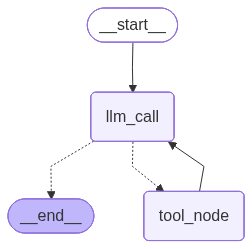

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_a0b472bee57e48c9b900d243)
 Call ID: call_a0b472bee57e48c9b900d243
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [45]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()